In [1]:
# Import necessary libraries for data manipulation, model building, and evaluation
%matplotlib inline
from hmmlearn import hmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from modelFuncs import dataExtracterDays, HMM_predict
scaler = StandardScaler()

## Load and Prepare

First we load in the functions and data we need. I pull from the NVO ticker


In [2]:
ticker = 'NVO'
def feature_prep(df, vol_window=10, mom_window=5):
    df['Return'] = df['Close'].pct_change()
    df['LogReturn'] = np.log(1 + df['Return'])
    df['Volatility'] = df['Return'].rolling(vol_window).std()
    df['Momentum'] = df['Close'].pct_change(mom_window)
    df = df.dropna()
    return df

df_nvo = dataExtracterDays(ticker, '2016-01-01', '2026-01-01')
df_nvo

[*********************100%***********************]  1 of 1 completed

The dataset has observations across 2514 days


,Date,Open,High,Low,Close
0,2016-01-04,23.377434,23.385524,22.952684,23.179216
1,2016-01-05,23.450246,23.527105,23.292482,23.454290
2,2016-01-06,23.078088,23.300576,23.053818,23.175175
3,2016-01-07,22.693787,22.839416,22.511752,22.673561
4,2016-01-08,22.665469,22.709967,22.099137,22.151724
...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001


In [3]:
df_nvo = feature_prep(df_nvo)
df_nvo

,Date,Open,High,Low,Close,Return,LogReturn,Volatility,Momentum
10,2016-01-19,21.714843,21.755295,21.391224,21.520672,0.001506,0.001505,0.018116,-0.024390
11,2016-01-20,21.172780,21.565168,20.857252,21.395267,-0.005827,-0.005844,0.016862,-0.045824
12,2016-01-21,21.613710,21.735067,21.346724,21.569212,0.008130,0.008097,0.017653,-0.014964
13,2016-01-22,21.917103,22.248812,21.900921,22.143637,0.026632,0.026283,0.019691,-0.004003
14,2016-01-25,22.289261,22.588609,22.204311,22.353985,0.009499,0.009454,0.018519,0.040286
...,...,...,...,...,...,...,...,...,...
2509,2025-12-24,52.849998,53.630001,52.000000,52.560001,0.018407,0.018240,0.028437,0.100272
2510,2025-12-26,53.020000,53.029999,51.700001,52.400002,-0.003044,-0.003049,0.027850,0.100609
2511,2025-12-29,51.560001,51.990002,51.349998,51.470001,-0.017748,-0.017907,0.028685,0.070285
2512,2025-12-30,51.520000,51.669998,51.070000,51.220001,-0.004857,-0.004869,0.028786,0.064865


This will train on 2025-01-01 to 2025-10-21 and test on 2025-10-21 to 2026-01-01

In [4]:
Ntrain = 491
Nwindow = 30
NStates = 7

hmm_price, close, _, expected_pct_changes = HMM_predict(df_nvo, train_size=Ntrain, window_size=Nwindow, Ncomp=NStates, doprint=True)

State-wise means: [-0.1   -0.596  0.323  0.105  0.858  0.312 -1.209  2.586 -2.365  0.704
 -0.416  0.655 -0.355 -0.526 -0.528  0.324  0.928  0.37   0.403 -0.339
 -0.039]
State-wise std: [0.41798989 0.32324748 0.34598718 0.61662255 0.72837926 1.0171632
 2.22119403 0.79051019 1.30654043 0.46999462 0.26704417 0.47267572
 0.61791254 0.31650641 0.41089186 1.45660236 0.75218958 1.17115846
 0.76231368 0.29250217 0.33434015]
State counts: [140  58  27  63 116  58  29]
0
[[0.59 0.   0.   0.2  0.16 0.02 0.01]
 [0.   0.   0.   0.06 0.09 0.82 0.03]
 [0.   0.   0.86 0.   0.04 0.1  0.  ]
 [0.75 0.   0.02 0.21 0.   0.   0.02]
 [0.   0.   0.01 0.01 0.76 0.05 0.18]
 [0.   0.96 0.   0.04 0.   0.   0.  ]
 [0.   0.   0.06 0.73 0.   0.   0.2 ]]
Date for day before first prediction: 2017-12-27
Date for first day of real data: 2017-12-28


From the predictions we want to generate buy/sell signals. This is based on whether returns are above or below a threshold, and also on short- and long term exponential moving averages to identify trends. This is of course causal, so the function only knows about past prices, and the one-day-ahead predicted price.  

In [5]:
def GenerateSignals(obs, expected_pct_changes, threshold=0):
    signals = []
    last_pos = -1 #Start OUT 
    
    
    predict_size = len(expected_pct_changes)
    relevant_prices = obs['Close'].iloc[-predict_size-20:]
    
    fast_ema = relevant_prices.ewm(span=2, adjust=False).mean()
    slow_ema = relevant_prices.ewm(span=6, adjust=False).mean()


    for i in range(predict_size):
        #Match indices
        idx = i + 20 
        curr_p = relevant_prices.iloc[idx]
        f_ema = fast_ema.iloc[idx]
        s_ema = slow_ema.iloc[idx]
        expected_return = expected_pct_changes[i]


        is_bullish = expected_return > threshold or curr_p > f_ema 
        is_bearish = expected_return < -threshold and curr_p < s_ema

        # 1 = buy/hold
        # -1 = sell
        if last_pos <= 0:
            curr_sig = 1 if is_bullish else -1
        else:
            curr_sig = -1 if is_bearish else 1
            
        signals.append(curr_sig)
        last_pos = curr_sig
        
    return signals

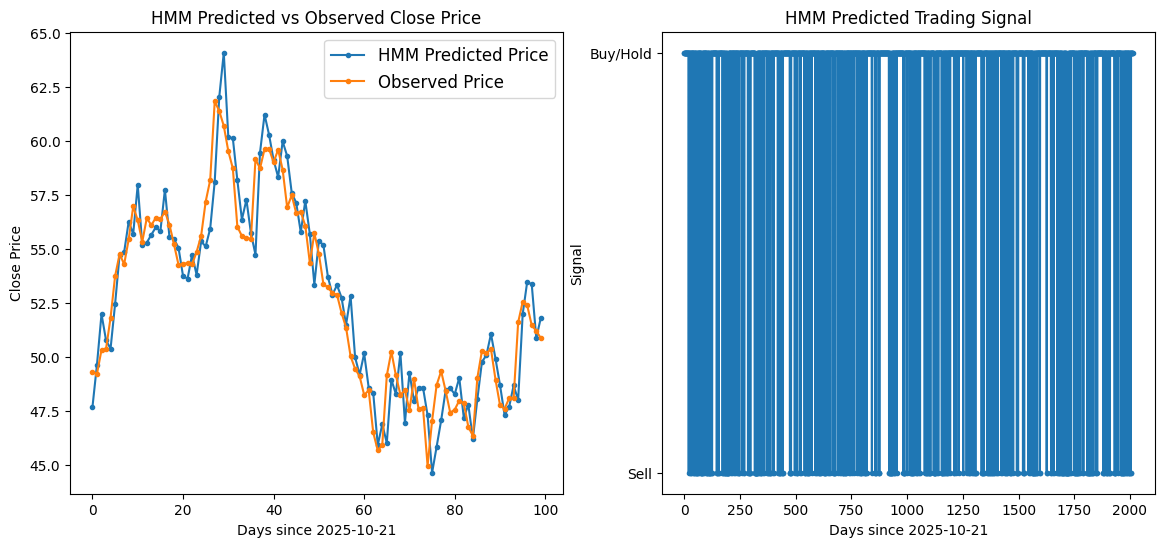

In [6]:
signals = GenerateSignals(df_nvo, expected_pct_changes, 0)
fig, ax = plt.subplots(figsize=(14, 6), ncols = 2)
hmm_price_array = np.array(hmm_price)

ax[0].plot(hmm_price_array[-100:],marker='.', label = "HMM Predicted Price")
ax[0].plot(close[-100:],marker = '.', label= "Observed Price")
ax[0].set_ylabel("Close Price")
ax[0].set_xlabel("Days since 2025-10-21")
ax[0].set_title("HMM Predicted vs Observed Close Price")
ax[0].legend(fontsize=12)
ax[1].plot(signals,marker='.', label = "HMM Predicted Signal")
ax[1].set_ylabel("Signal")
ax[1].set_xlabel("Days since 2025-10-21")
ax[1].set_yticks([-1, 1], ['Sell', 'Buy/Hold'])
ax[1].set_title("HMM Predicted Trading Signal")
plt.show()

Now we translate the signal into a portfolio value based on a simple binary model (own 0 or 1 asset at any one time)

In [7]:
def trading_strat(signals, close):
    """
    Simulate trading based on signals:
    - Buy/Hold = 1
    - Sell = -1

    Owns either 0 or 1 unit of stock at any time

    Returns:
        values: portfolio value at each step
        positions: 0 or 1 stock held at each step
    """
    n = len(signals)
    values = np.zeros(n)      # Portfolio value
    positions = np.zeros(n)   # 0 or 1 stock held

    stocks_owned = 0
    cash = 0

    for i in range(n):
        if signals[i] == 1:  #Buy/Hold
            if stocks_owned == 0:
                stocks_owned = 1
                cash -= close[i]  #Spend money to buy
        elif signals[i] == -1:  #Sell
            if stocks_owned == 1:
                stocks_owned = 0
                cash += close[i]  #Receive cash from selling

        positions[i] = stocks_owned
        values[i] = cash + stocks_owned * close[i]  # Total portfolio value

    return values, positions

values, positions = trading_strat(signals, close)

Plotting

In [10]:
def plot_trading_signals(obs, hmm_price, close, signals, values):
    close = np.array(close)
    signals = np.array(signals)
    values = np.array(values)

    buy_indices = np.where(signals == 1)[0]
    sell_indices = np.where(signals == -1)[0]
    
    dates = obs['Date']

    plt.figure(figsize=(8,6))
    
    #Plot close price
    plt.plot(close, label='Close Price', color='blue')
    values = values + close[0]  # Normalize portfolio value to start at the same point as price
    print(close[0], values[0])
    #Plot portfolio value
    plt.plot(values, label='Portfolio Value', color='green', linestyle='--')
    #Plot the predicted price
    plt.plot(hmm_price, label='Predicted Price', color='orange', linestyle='-.')
    
    #Plot buy/sell signals
    plt.scatter(buy_indices, close[buy_indices], marker='^', color='green', s=100, label='Buy Signal')
    plt.scatter(sell_indices, close[sell_indices], marker='v', color='red', s=100, label='Sell Signal')
    
    plt.title(f"HMM Trading Signals for {ticker}", fontsize=14)
    plt.xlabel("Date", fontsize=13)
    plt.ylabel("Price / Portfolio Value", fontsize=13)

    num_ticks = 6
    tick_idx = np.linspace(0, len(dates) - 1, num_ticks, dtype=int)
    plt.xticks(tick_idx, dates.iloc[tick_idx], rotation=0)
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.savefig('trading_signals.pdf')
    plt.show()

49.314300537109375 49.314300537109375


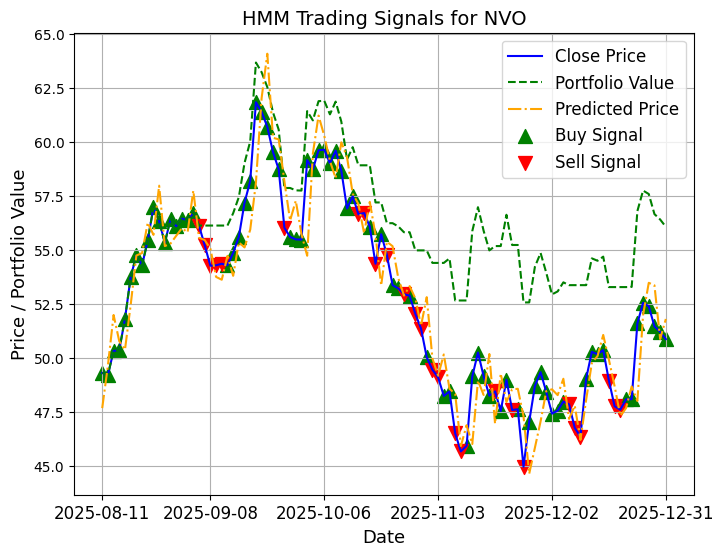

In [11]:
signals = GenerateSignals(df_nvo, expected_pct_changes, 0)
values, positions = trading_strat(signals[-100:], close[-100:])
plot_trading_signals(df_nvo[-100:],hmm_price[-100:], close[-100:], signals[-100:], values[-100:])

The trading strategy is primitive and far from perfect, but the signals are good enough to be used for a viable trading strategy. It is the signal generation process that needs tweaking